In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_theme(style="whitegrid")

**Data Loading & Exploration**

In [3]:
from google.colab import drive

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Housing.csv')

print("--- First 10 Rows of the Dataset ---")
display(df.head(10))

rows, cols = df.shape
print(f"\nDataset Dimensions: {rows} rows and {cols} columns.")

print("\nTarget Variable: 'price'")
print(f"Feature Variables: {list(df.columns.drop('price'))}")

print("\nMissing Values Per Column")
print(df.isnull().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- First 10 Rows of the Dataset ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Dataset Dimensions: 545 rows and 13 columns.

Target Variable: 'price'
Feature Variables: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing Values Per Column
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


**Data Cleaning**

In [4]:
df = df.dropna()

duplicate_count = df.duplicated().sum()
print(f"Removed {duplicate_count} duplicate rows.")
df = df.drop_duplicates()

categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns to encode: {list(categorical_cols)}")
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first="1").astype(int)

print("\nShape after encoding:", df_encoded.shape)
df_encoded.head()

Removed 0 duplicate rows.

Categorical columns to encode: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Shape after encoding: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


**Model Building**

In [5]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

#Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

#Random Forest Regressor Model
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"=== {model_name} Performance ===")
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print(f"R² Score (Variance Explained): {r2:.4f}\n")
    return mae, rmse, r2
lr_results = evaluate_model(y_test, y_pred_lr, "Linear Regression")
rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

Training set size: 436 samples
Test set size: 109 samples
=== Linear Regression Performance ===
Mean Absolute Error (MAE): $970,043.40
Root Mean Squared Error (RMSE): $1,324,506.96
R² Score (Variance Explained): 0.6529

=== Random Forest Regressor Performance ===
Mean Absolute Error (MAE): $1,021,546.04
Root Mean Squared Error (RMSE): $1,400,565.97
R² Score (Variance Explained): 0.6119



**Visualization**

Chart 1: Histogram of House Prices


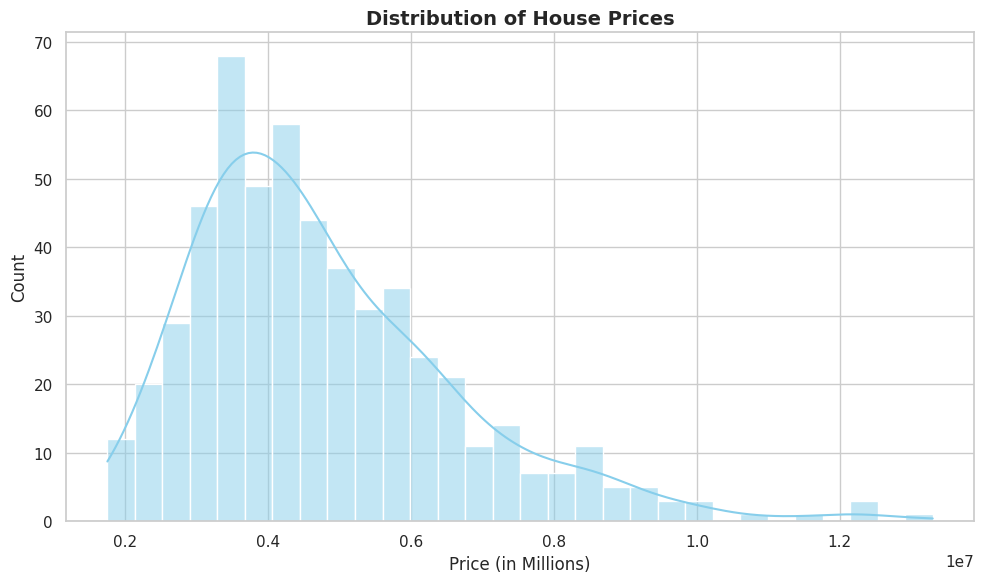

Chart 2: Correlation Heatmap


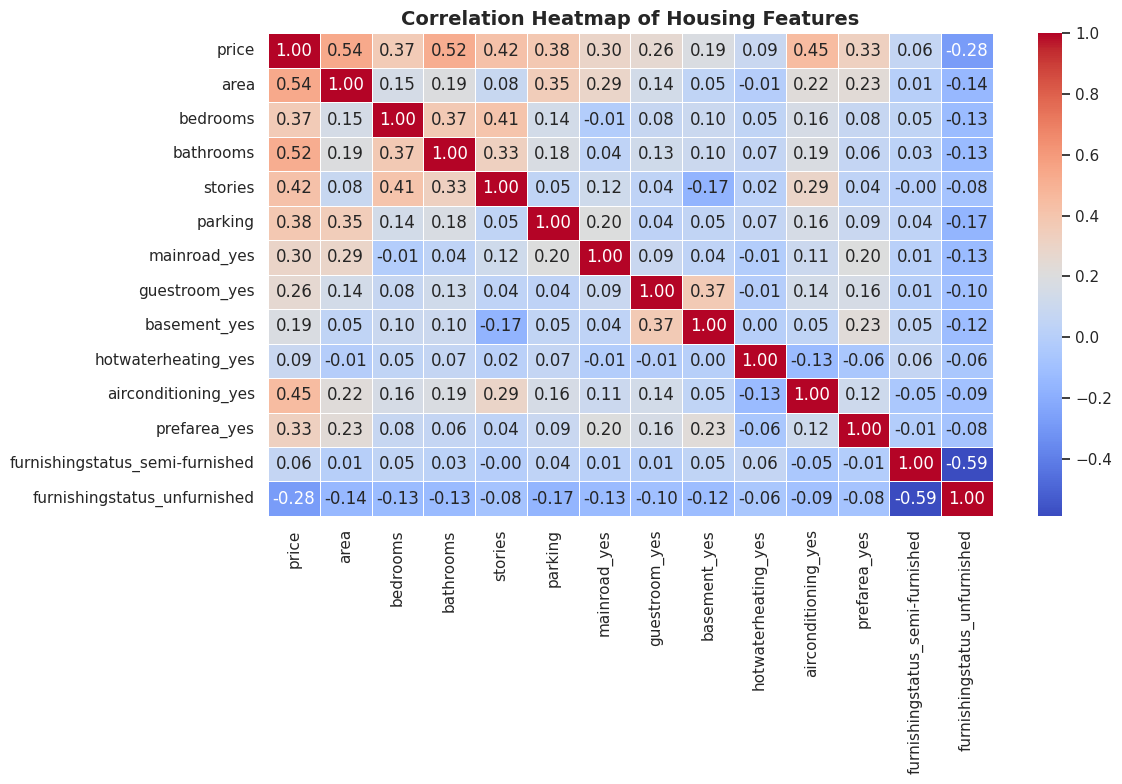

Chart 3: Actual vs Predicted Prices


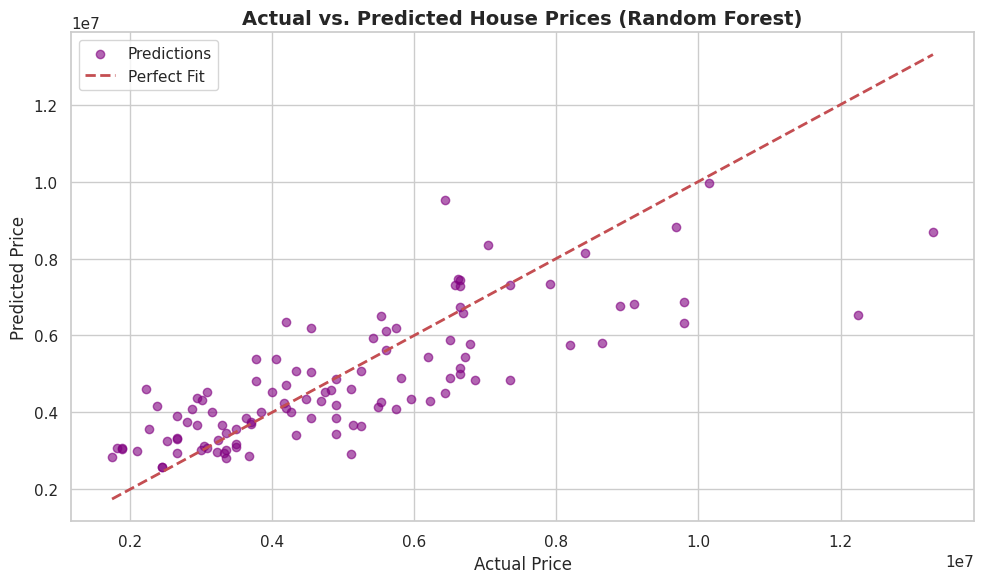

In [6]:
import os
os.makedirs('charts', exist_ok=True)
print("Chart 1: Histogram of House Prices")
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (in Millions)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png')
plt.show()
print("Chart 2: Correlation Heatmap")
plt.figure(figsize=(12, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Housing Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png')
plt.show()
print("Chart 3: Actual vs Predicted Prices")
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='purple', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title('Actual vs. Predicted House Prices (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png')
plt.show()

**Insights & Summary**

1.
According to the Correlation Heatmap, the things that make a house price go up the most are:
Area, which has a strong connection to house price. This means that as the area of the house gets bigger the price goes up a lot.
Bathrooms, which's really close to area. This shows that having Bathrooms makes a house worth a lot more.
Having air conditioning and multiple stories which're also important. Having these things in a house makes it worth more.

2.
If we look at the Actual vs Predicted House Prices plot:
For houses that are not too expensive the model is really good. The dots are all close to the line where the actual price. Predicted price are the same.
For expensive houses the model is not as good. It thinks these houses are worth less than they really're. You can see the dots are away from the line.

3.
It is surprising that having bathrooms makes a house worth more than having more bedrooms.
Also if a house is not furnished it is worth less. This shows that people want houses that're ready to move in.
There are also some houses that're really expensive much more than most houses. These houses make it hard for the model to guess the price.

4.
If a real estate business wants to make a house worth more they should focus on making the house bigger and more comfortable. They should add air conditioning or another bathroom. This is because people are willing to pay more for a house that's nice and comfortable not just a house, with a lot of bedrooms. The data shows that people pay more for houses that're nice and have the things they want.